In [12]:
# this notebook is not complete, try it as a challenge
# we want to find all the streets that are more than 2 travels lanes by a school

import requests
import geopandas as gpd
import pandas as pd

OVERPASS_URL = "https://overpass-api.de/api/interpreter"

def query_overpass(
    bbox: tuple,
    tags: dict,
    element_types: list[str] = ["node", "way", "relation"]
) -> dict:
    south, west, north, east = bbox
    bbox_str = f"({south},{west},{north},{east})"
    tag_str = "".join(f"[{k}={v}]" for k, v in tags.items())

    statements = "\n".join(
        f"  {el}{tag_str}{bbox_str};" for el in element_types
    )

    query = f"""
    [out:json][timeout:25];
    (
    {statements}
    );
    out geom;
    """

    response = requests.get(
        OVERPASS_URL,
        params={"data": query},
        headers={"User-Agent": "python-app/1.0"},
        timeout=30
    )
    response.raise_for_status()

    return elements_to_geojson(response.json().get("elements", []))


def elements_to_geojson(elements: list[dict]) -> dict:
    """Convert a list of Overpass API elements to a GeoJSON FeatureCollection."""
    features = []

    for el in elements:
        el_type = el.get("type")
        props = {**el.get("tags", {}), "osm_id": el.get("id"), "osm_type": el_type}

        if el_type == "node":
            geometry = {
                "type": "Point",
                "coordinates": [el["lon"], el["lat"]]
            }

        elif el_type == "way":
            coords = [[n["lon"], n["lat"]] for n in el.get("geometry", [])]
            # Close the ring if the way is a polygon
            is_polygon = coords and coords[0] == coords[-1]
            geometry = {
                "type": "Polygon" if is_polygon else "LineString",
                "coordinates": [coords] if is_polygon else coords
            }

        elif el_type == "relation":
            # Outer members become the polygon shell; inner members become holes
            outer, inner = [], []
            for member in el.get("members", []):
                ring = [[n["lon"], n["lat"]] for n in member.get("geometry", [])]
                if not ring:
                    continue
                if member.get("role") == "inner":
                    inner.append(ring)
                else:
                    outer.append(ring)
            geometry = {"type": "MultiPolygon" if len(outer) > 1 else "Polygon",
                        "coordinates": outer + inner}

        else:
            continue

        features.append({"type": "Feature", "geometry": geometry, "properties": props})

    return {"type": "FeatureCollection", "features": features}

In [3]:
# https://www.openstreetmap.org/way/5678676#map=17/40.731507/-73.955723
# grab all residential streets
geojson = query_overpass(
    bbox=(40.6738536, -74.024131, 40.7416114, -73.9182042), # (south, west, north, east) = (min_lat, min_lon, max_lat, max_lon)
    tags={"highway": "residential"},
    element_types=["way"]
)

In [6]:
geojson

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'geometry': {'type': 'LineString',
    'coordinates': [[-73.975304, 40.7265403],
     [-73.9753206, 40.7265364],
     [-73.9753371, 40.7265145],
     [-73.9757178, 40.7260092],
     [-73.9757383, 40.725982],
     [-73.975785, 40.72592],
     [-73.9758995, 40.7257607],
     [-73.9761335, 40.7254408],
     [-73.976163, 40.7254001],
     [-73.9762137, 40.725334]]},
   'properties': {'foot': 'use_sidepath',
    'highway': 'residential',
    'lit': 'yes',
    'maxspeed': '20 mph',
    'name': 'Szold Place',
    'name:etymology:wikidata': 'Q469664',
    'oneway': 'yes',
    'sidewalk:both': 'separate',
    'surface': 'asphalt',
    'osm_id': 5668983,
    'osm_type': 'way'}},
  {'type': 'Feature',
   'geometry': {'type': 'LineString',
    'coordinates': [[-73.9959296, 40.7328696],
     [-73.9960197, 40.7329068],
     [-73.9987019, 40.7340344]]},
   'properties': {'bicycle': 'yes',
    'cycleway:left': 'lane',
    'cycleway:rig

In [8]:
# read it into geopandas, we want geojson["features"] since it is an array of items 
residential_streets = gpd.GeoDataFrame.from_features(geojson["features"], crs = 4326)

<Axes: >

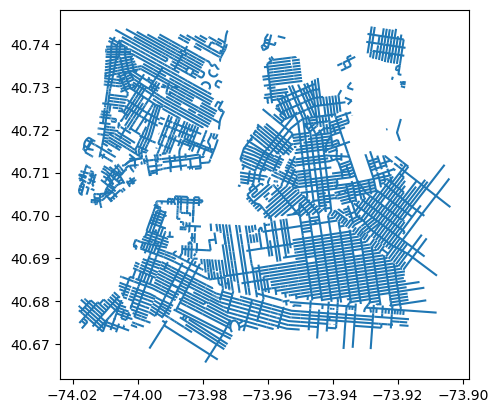

In [10]:
residential_streets.plot()

In [13]:
# https://data.cityofnewyork.us/Education/School-Point-Locations/jfju-ynrr/about_data

# get all schools 
URL = 'https://ws.schools.nyc/schooldata/GetSchools?search=&borough='
r = requests.get(url = URL, verify=False)
data = r.json() 
df = pd.DataFrame(data)
df.sample(2)

C:\Users\zhe5\AppData\Local\miniconda3\envs\class\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ws.schools.nyc'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,locationCode,type,boroughName,boroughCode,name,phoneNumber,primaryAddressLine,zip,grades,stateCode,x,y,profile,neighborhood,district,distance,dataflag
1602,Q134,DOE,Queens,Q,P.S. 134 Hollis,718-464-5544,203-02 109 Avenue,11412,"PK,0K,01,02,03,04,05,SE",NY,-8210340.87960000,4969298.38290000,,Hollis ...,29,,L
1665,Q203,DOE,Queens,Q,P.S. 203 Oakland Gardens,718-423-8652,53-11 SPRINGFIELD BOULEVARD,11364,"PK,0K,01,02,03,04,05,SE",NY,-8210905.82600000,4976066.25480000,,Oakland Gardens ...,26,,L


In [15]:
schools = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df['x'], df['y']), crs = 102100).to_crs(4326)

<Axes: >

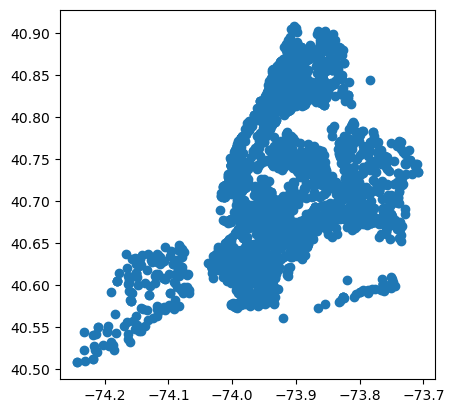

In [16]:
schools.plot()